In [1]:
import pandas as pd
pd.set_option("display.max_columns", None)

In [2]:
data = pd.read_parquet("creditcard.parquet")
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Load dataset
#df = pd.read_csv("creditcard.csv")  # download from Kaggle first

# 2. Features & target
X = data.drop("Class", axis=1)   # all features
y = data["Class"]                # fraud = 1, normal = 0

# 3. Train-test split (stratified to handle imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 4. Train model
model = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 5. Evaluate
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.97      0.70      0.82       148

    accuracy                           1.00     85443
   macro avg       0.99      0.85      0.91     85443
weighted avg       1.00      1.00      1.00     85443

ROC-AUC: 0.9275490230250181


In [4]:
# Feature important

import pandas as pd

# Get feature importances
importances = model.feature_importances_

# Match importances with feature names
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

# Sort by importance (descending)
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df)


   Feature  Importance
14     V14    0.184737
4       V4    0.120592
10     V10    0.117282
12     V12    0.101505
17     V17    0.089209
3       V3    0.064733
11     V11    0.046731
16     V16    0.042720
2       V2    0.036023
9       V9    0.026257
21     V21    0.022654
7       V7    0.013901
19     V19    0.011740
18     V18    0.011717
29  Amount    0.009878
6       V6    0.008905
5       V5    0.008691
27     V27    0.007971
28     V28    0.007827
13     V13    0.007548
26     V26    0.007331
8       V8    0.006932
22     V22    0.006888
15     V15    0.006679
1       V1    0.005901
20     V20    0.005685
25     V25    0.005684
23     V23    0.005040
0     Time    0.004673
24     V24    0.004564


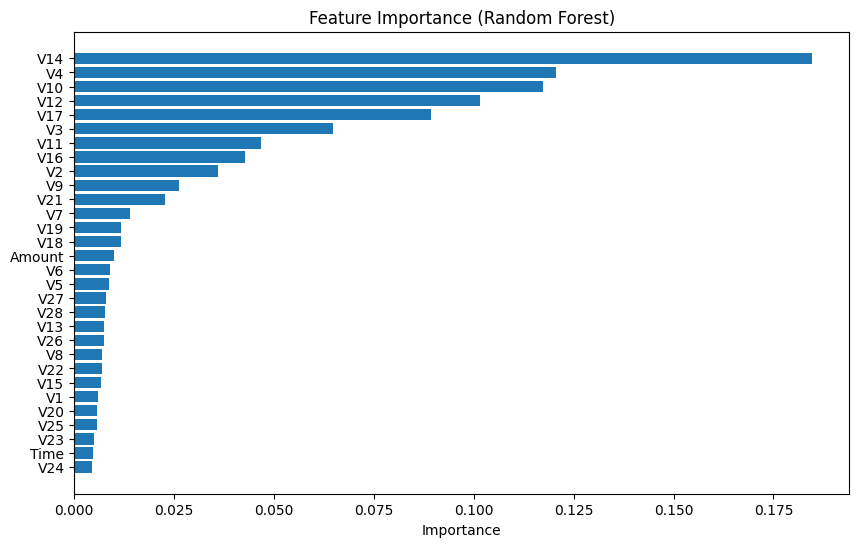

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.gca().invert_yaxis()  # Highest importance on top
plt.xlabel('Importance')
plt.title('Feature Importance (Random Forest)')
plt.show()


100%|===================| 398500/398728 [21:39<00:00]        

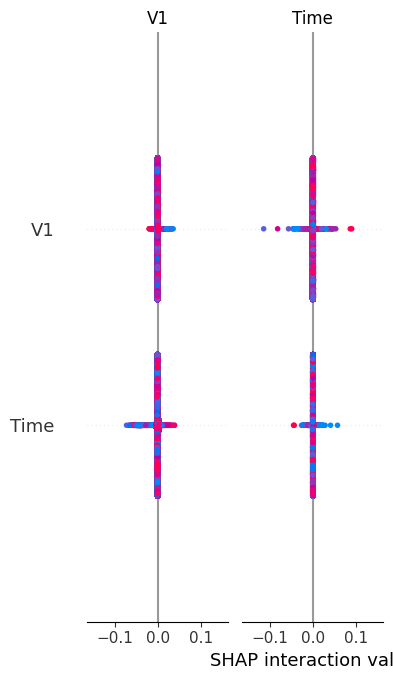

In [7]:
import shap

# --- Step 1: Create the explainer ---
explainer = shap.Explainer(model, X_train)

# --- Step 2: Compute SHAP values ---
shap_values = explainer(X_train)

# --- Step 3: Plot global feature importance ---
shap.summary_plot(shap_values, X_train)


In [8]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import shap

def shap_feature_selection(model, X_train, X_test, y_train, y_test, top_frac=0.95):
    """
    Performs SHAP-based feature selection and compares model performance before & after.
    
    Parameters
    ----------
    model : trained sklearn model
        Your fitted RandomForestClassifier or similar model.
    X_train, X_test : pandas DataFrame
        Training and testing feature sets.
    y_train, y_test : array-like
        Target values.
    top_frac : float, optional
        Fraction of cumulative SHAP importance to keep (default = 0.95)
    """
    
    # --- Step 1: Compute SHAP values ---
    explainer = shap.Explainer(model, X_train)
    shap_values = explainer(X_train)

    # --- Step 2: Compute mean absolute SHAP importance ---
    shap_importance = np.abs(shap_values.values).mean(axis=0)
    shap_importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Mean_Abs_SHAP': shap_importance
    }).sort_values('Mean_Abs_SHAP', ascending=False)

    # --- Step 3: Select top features based on cumulative contribution ---
    shap_importance_df['Cumulative'] = shap_importance_df['Mean_Abs_SHAP'].cumsum() / shap_importance_df['Mean_Abs_SHAP'].sum()
    selected_features = shap_importance_df.loc[shap_importance_df['Cumulative'] <= top_frac, 'Feature']
    X_train_sel = X_train[selected_features]
    X_test_sel = X_test[selected_features]

    # --- Step 4: Retrain model on selected features ---
    model.fit(X_train_sel, y_train)
    y_pred_sel = model.predict(X_test_sel)

    # --- Step 5: Compare performance ---
    results = {
        "n_features_before": X_train.shape[1],
        "n_features_after": len(selected_features),
        "accuracy": accuracy_score(y_test, y_pred_sel),
        "f1_score": f1_score(y_test, y_pred_sel, average='weighted'),
        "precision": precision_score(y_test, y_pred_sel, average='weighted'),
        "recall": recall_score(y_test, y_pred_sel, average='weighted')
    }

    print("=== SHAP Feature Selection Summary ===")
    print(f"Selected {len(selected_features)} / {X_train.shape[1]} features ({top_frac*100:.1f}% cumulative importance)\n")
    print(pd.DataFrame([results]))
    print("\nTop selected features:")
    print(selected_features.tolist())

    return shap_importance_df, selected_features, results


In [9]:
# Assume you already trained your model as:
# model = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Run SHAP-based selection
shap_df, selected_features, results = shap_feature_selection(model, X_train, X_test, y_train, y_test)


100%|===================| 398538/398728 [19:40<00:00]        

ValueError: Per-column arrays must each be 1-dimensional